# NIFTY50 Alpha#1 Guided Research Notebook

**Goal:** learn, compute, test, rank, and regime-analyze the first alpha from *101 Formulaic Alphas* on NIFTY50 stocks.

This notebook is intentionally educational. It is not a production trading system. It helps answer:

1. What does Alpha#1 measure?
2. Does it have predictive information for NIFTY50 stocks?
3. Which holding horizon looks most promising?
4. Which stocks respond best to this alpha?
5. Which market regimes help or hurt it?
6. Can we produce a first-pass confidence score for future trade-candidate generation?

**MFT framing:** this notebook treats Alpha#1 as a research signal. A real trade idea should only be created after validation and should remain human-reviewed.

## 0. Storage path inside the repo

Recommended repo path:

```text
research/notebooks/nifty50_alpha001_guided_research.ipynb
```

Recommended generated outputs:

```text
research/artifacts/alpha001_nifty50/
├── alpha001_scores.csv
├── ic_by_horizon.csv
├── bucket_returns.csv
├── strategy_metrics.csv
├── stock_ranking.csv
├── regime_report.csv
└── latest_trade_candidates.csv
```

This follows the repo's research workspace pattern: notebooks are for research/review, while canonical mutation should stay in CLI/project code.

## 1. What Alpha#1 is

From *101 Formulaic Alphas*:

```text
Alpha#1 =
rank(
    ts_argmax(
        signedpower(
            ((returns < 0) ? stddev(returns, 20) : close),
            2
        ),
        5
    )
) - 0.5
```

Plain-English version:

1. For each stock, compute daily return.
2. If today's return is negative, use the stock's 20-day return volatility.
3. Otherwise, use the stock's close price.
4. Square that value using `signedpower`.
5. Find where the maximum occurred in the last 5 days using `ts_argmax`.
6. Rank this value across all stocks on the same date.
7. Subtract `0.5` so the signal is centered around zero.

**Important:** this is a **cross-sectional alpha**. It should be computed across the full universe on each date, not stock-by-stock in isolation.

## 2. How we will test it

We will test Alpha#1 in layers:

### A. Signal quality
Does today's Alpha#1 score correlate with future returns?

Metrics:
- Information Coefficient (IC)
- Rank IC
- ICIR
- positive IC rate
- horizon comparison: 1d, 3d, 5d, 10d

### B. Bucket behavior
Do top-ranked stocks outperform bottom-ranked stocks?

Metrics:
- top bucket forward return
- bottom bucket forward return
- top-minus-bottom spread

### C. Tradable basket backtest
Can a simple portfolio use this signal?

Strategies:
- long top 5
- long top 10
- long top 5 / short bottom 5
- long top 10 / short bottom 10

### D. Regime analysis
When does the alpha work?

Regimes:
- NIFTY trend: bull / bear / sideways
- NIFTY volatility: low / medium / high

### E. Stock ranking
Which stocks are most suitable for this alpha?

In [1]:
# 3. Imports and environment checks

from __future__ import annotations

import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError(
        "yfinance is required. Install with: pip install yfinance pandas numpy matplotlib"
    ) from exc

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Environment ready")

Environment ready


In [2]:
# 4. Configuration

START_DATE = "2018-01-01"
END_DATE = None  # None means latest available from yfinance

# Keep horizons short because the original formulaic alphas are short-horizon by design.
FORWARD_HORIZONS = [1, 3, 5, 10]

TOP_N_VALUES = [5, 10]
ROUND_TRIP_COST_BPS = 10.0  # change this for sensitivity testing

OUTPUT_DIR = Path("research/artifacts/alpha001_nifty50")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Current-style NIFTY50 default universe.
# For production research, replace this with point-in-time index membership.
NIFTY50_SYMBOLS = [
    "ADANIENT", "ADANIPORTS", "APOLLOHOSP", "ASIANPAINT", "AXISBANK",
    "BAJAJ-AUTO", "BAJFINANCE", "BAJAJFINSV", "BEL", "BHARTIARTL",
    "CIPLA", "COALINDIA", "DRREDDY", "EICHERMOT", "GRASIM",
    "HCLTECH", "HDFCBANK", "HDFCLIFE", "HEROMOTOCO", "HINDALCO",
    "HINDUNILVR", "ICICIBANK", "INDUSINDBK", "INFY", "ITC",
    "JIOFIN", "JSWSTEEL", "KOTAKBANK", "LT", "M&M",
    "MARUTI", "NESTLEIND", "NTPC", "ONGC", "POWERGRID",
    "RELIANCE", "SBILIFE", "SHRIRAMFIN", "SBIN", "SUNPHARMA",
    "TATACONSUM", "TATAMOTORS", "TATASTEEL", "TCS", "TECHM",
    "TITAN", "TRENT", "ULTRACEMCO", "WIPRO"
]

YF_TICKERS = [f"{symbol}.NS" for symbol in NIFTY50_SYMBOLS]
SYMBOL_FROM_TICKER = dict(zip(YF_TICKERS, NIFTY50_SYMBOLS))

NIFTY_INDEX_TICKER = "^NSEI"

print(f"Universe size: {len(NIFTY50_SYMBOLS)}")
print(f"Output dir: {OUTPUT_DIR}")

Universe size: 49
Output dir: research/artifacts/alpha001_nifty50


## 5. Download NIFTY50 OHLCV data

We use Yahoo Finance for fast research. For production-grade research, prefer your project's canonical data ingestion and dataset snapshots.

**Data-quality warning:** Yahoo Finance data can have missing rows, symbol failures, corporate-action issues, and occasional stale values. This notebook includes basic checks, but it is not a substitute for a governed data pipeline.

In [3]:
def download_yf_panel(tickers: list[str], start: str, end: str | None = None) -> pd.DataFrame:
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False,
    )
    if data.empty:
        raise ValueError("No data downloaded from yfinance.")
    return data


raw = download_yf_panel(YF_TICKERS, START_DATE, END_DATE)
raw.head()

/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future versio

Ticker          M&M.NS                                                          HDFCBANK.NS                                                           \
Price             Open        High         Low       Close   Adj Close   Volume        Open        High         Low       Close   Adj Close   Volume   
Date                                                                                                                                                   
2018-01-01  751.000000  758.900024  743.000000  744.650024  692.009399  2476302  468.174988  470.187500  462.625000  463.625000  432.688995  6580516   
2018-01-02  754.000000  758.000000  746.299988  752.900024  699.676147  3020597  464.637512  468.750000  464.637512  468.087494  436.853790  4776316   
2018-01-03  755.900024  759.000000  750.000000  754.900024  701.534729  2256643  468.750000  469.562500  462.799988  463.162506  432.257385  4531288   
2018-01-04  761.000000  761.000000  750.500000  756.000000  702.556946  1663380  463.250000  466.375000  463.250000  464.975006  433.948975  2373776   
2018-01-05  756.000000  758.500000  753.599976  756.349976  702.882202  1255982  465.750000  467.012512  463.887512  465.899994  434.812225  2870868   

Ticker         SBIN.NS                                                                 TCS.NS                                                               \
Price             Open        High         Low       Close   Adj Close    Volume         Open         High          Low        Close    Adj Close   Volume   
Date                                                                                                                                                         
2018-01-01  310.600006  312.750000  306.299988  307.100006  278.349030  12182400  1341.150024  1347.400024  1317.500000  1322.800049  1083.771362  1351760   
2018-01-02  309.000000  309.000000  301.350006  303.250000  274.859467  14797364  1330.000000  1334.800049  1310.099976  1315.599976  1077.872925  1920290   
2018-01-03  305.299988  306.450012  302.149994  302.850006  274.496918  13857373  1316.000000  1334.500000  1315.599976  1319.324951  1080.924194  1257120   
2018-01-04  304.500000  310.200012  303.149994  308.500000  279.617950  24517099  1325.000000  1331.000000  1320.000000  1328.550049  1088.482666   913082   
2018-01-05  311.399994  311.399994  305.600006  306.350006  277.669220  14580575  1325.000000  1349.750000  1325.000000  1344.599976  1101.632202  1153706   

Ticker     TATASTEEL.NS                                                       EICHERMOT.NS                                                             \
Price              Open       High        Low      Close  Adj Close    Volume         Open        High          Low        Close    Adj Close  Volume   
Date                                                                                                                                                    
2018-01-01    69.787956  70.064255  68.549400  68.806641  55.281414  19249201  3039.995117  3042.00000  2985.000000  2989.314941  2795.703613  198470   
2018-01-02    68.978134  69.668869  68.144485  69.483086  55.824894  25896915  2992.500000  2995.50000  2853.969971  2867.014893  2681.324951  847930   
2018-01-03    69.740318  70.264328  69.668869  70.021378  56.257366  27654851  2885.000000  2904.50000  2854.215088  2881.435059  2694.810791  470880   
2018-01-04    70.169052  72.736679  69.740318  72.431801  58.193981  84839667  2882.570068  2895.76001  2841.500000  2857.074951  2672.028564  494210   
2018-01-05    72.789078  74.018112  72.646172  73.427414  58.993885  74902157  2879.699951  2932.50000  2868.620117  2923.699951  2734.338623  527770   

Ticker     HDFCLIFE.NS                                                          JSWSTEEL.NS                                                           \
Price             Open        High         Low       Close   Adj Close   Volume        Open        High         Low       Close   Adj Close  

In [4]:
# 6. Convert yfinance's multi-index output into field x symbol dataframes.

def extract_field(raw_data: pd.DataFrame, field: str) -> pd.DataFrame:
    frames = {}
    for ticker in YF_TICKERS:
        symbol = SYMBOL_FROM_TICKER[ticker]
        try:
            series = raw_data[(ticker, field)]
        except KeyError:
            continue
        frames[symbol] = series
    return pd.DataFrame(frames).sort_index()


open_px = extract_field(raw, "Open")
close_px = extract_field(raw, "Close")
adj_close_px = extract_field(raw, "Adj Close")
volume = extract_field(raw, "Volume")

# Use adjusted close for return measurement when available, but keep close for the paper formula.
return_close = adj_close_px.where(adj_close_px.notna(), close_px)

print("Shapes:")
print("open", open_px.shape)
print("close", close_px.shape)
print("adj_close", adj_close_px.shape)
print("volume", volume.shape)

missing_ratio = close_px.isna().mean().sort_values(ascending=False)
display(missing_ratio.head(10).to_frame("missing_close_ratio"))

Shapes:
open (2068, 49)
close (2068, 49)
adj_close (2068, 49)
volume (2068, 49)


,missing_close_ratio
TATAMOTORS,1.000000
JIOFIN,0.676015
APOLLOHOSP,0.000000
ADANIPORTS,0.000000
AXISBANK,0.000000
BAJAJ-AUTO,0.000000
BAJFINANCE,0.000000
ASIANPAINT,0.000000
BEL,0.000000
BHARTIARTL,0.000000


## 7. Data quality filter

For the first research pass, we drop symbols with too much missing data.

Later, in the MFT production workflow, this should be replaced by the project's data quality and snapshot system.

In [5]:
MAX_MISSING_RATIO = 0.15

usable_symbols = missing_ratio[missing_ratio <= MAX_MISSING_RATIO].index.tolist()

open_px = open_px[usable_symbols]
close_px = close_px[usable_symbols]
return_close = return_close[usable_symbols]
volume = volume[usable_symbols]

# Forward-fill small gaps, then drop dates where too much of the universe is still missing.
open_px = open_px.ffill()
close_px = close_px.ffill()
return_close = return_close.ffill()
volume = volume.ffill()

min_symbols_per_day = max(10, int(0.8 * len(usable_symbols)))
valid_dates = close_px.notna().sum(axis=1) >= min_symbols_per_day

open_px = open_px.loc[valid_dates]
close_px = close_px.loc[valid_dates]
return_close = return_close.loc[valid_dates]
volume = volume.loc[valid_dates]

print(f"Usable symbols: {len(usable_symbols)} / {len(NIFTY50_SYMBOLS)}")
print(f"Date range: {close_px.index.min().date()} to {close_px.index.max().date()}")
print(f"Trading days: {len(close_px)}")

Usable symbols: 47 / 49
Date range: 2018-01-01 to 2026-05-18
Trading days: 2068


## 8. Alpha operator library

These helper functions implement the operators used by Alpha#1.

Key idea:

- `rank_cross_sectional`: rank all stocks on the same date.
- `ts_argmax`: rolling time-series argmax for each stock independently.
- `signed_power`: preserve sign while raising magnitude to a power.

Alpha#1 uses a 5-day `ts_argmax` and 20-day rolling volatility.

In [6]:
def signed_power(df: pd.DataFrame, power: float) -> pd.DataFrame:
    return np.sign(df) * (df.abs() ** power)


def ts_argmax(df: pd.DataFrame, window: int) -> pd.DataFrame:
    # Returns 1-based position of the maximum inside the rolling window.
    # 1 = oldest observation in window, window = latest observation.
    return df.rolling(window=window, min_periods=window).apply(
        lambda x: float(np.argmax(x) + 1),
        raw=True,
    )


def rank_cross_sectional(df: pd.DataFrame) -> pd.DataFrame:
    # Percentile rank across stocks for each date.
    return df.rank(axis=1, pct=True)


def compute_alpha001(close: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    rolling_vol_20 = returns.rolling(20, min_periods=20).std()
    conditional_value = close.where(returns >= 0, rolling_vol_20)
    powered = signed_power(conditional_value, 2.0)
    argmax_5 = ts_argmax(powered, 5)
    alpha = rank_cross_sectional(argmax_5) - 0.5
    return alpha

## 9. Compute Alpha#1

Interpretation of score:

- positive score: stock is high-ranked by Alpha#1 on that date
- negative score: stock is low-ranked by Alpha#1 on that date
- near zero: middle of the universe

Do **not** assume positive means buy yet. We must test the relationship with future returns.

In [7]:
daily_returns = return_close.pct_change()
alpha001 = compute_alpha001(close_px, daily_returns)

alpha001.to_csv(OUTPUT_DIR / "alpha001_scores.csv")

display(alpha001.tail())
print("Alpha score range:")
display(alpha001.stack().describe().to_frame("alpha001"))

,APOLLOHOSP,ADANIPORTS,AXISBANK,BAJAJ-AUTO,BAJFINANCE,ASIANPAINT,BEL,BHARTIARTL,CIPLA,COALINDIA,DRREDDY,EICHERMOT,GRASIM,BAJAJFINSV,ADANIENT,HDFCBANK,HCLTECH,HINDALCO,HDFCLIFE,ICICIBANK,INDUSINDBK,INFY,HEROMOTOCO,ITC,JSWSTEEL,KOTAKBANK,LT,M&M,MARUTI,NESTLEIND,HINDUNILVR,NTPC,ONGC,RELIANCE,POWERGRID,SHRIRAMFIN,SBIN,SUNPHARMA,SBILIFE,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-12,0.159574,0.393617,-0.361702,0.159574,-0.361702,0.159574,0.159574,0.159574,-0.361702,0.393617,-0.361702,-0.106383,0.393617,-0.361702,-0.361702,-0.361702,0.159574,-0.106383,-0.106383,-0.361702,0.159574,0.159574,-0.106383,0.159574,-0.106383,0.393617,-0.106383,-0.106383,-0.106383,-0.361702,0.393617,0.159574,0.500000,0.393617,0.159574,-0.106383,-0.361702,0.393617,0.393617,0.393617,-0.106383,-0.361702,-0.361702,0.159574,-0.106383,-0.106383,0.159574
2026-05-13,-0.106383,0.159574,0.159574,-0.106383,0.329787,0.446809,-0.106383,-0.106383,0.446809,0.159574,0.329787,-0.372340,0.159574,0.329787,0.446809,-0.372340,-0.106383,0.446809,-0.372340,0.159574,-0.106383,-0.106383,-0.372340,-0.106383,-0.372340,0.159574,-0.372340,-0.372340,-0.372340,-0.106383,0.159574,-0.106383,0.446809,0.159574,-0.106383,-0.372340,0.329787,0.159574,0.159574,0.159574,0.446809,0.329787,-0.106383,-0.106383,-0.372340,-0.372340,-0.106383
2026-05-14,0.255319,0.255319,-0.127660,-0.361702,0.255319,0.255319,-0.361702,0.255319,0.255319,-0.127660,0.255319,0.255319,-0.127660,0.255319,0.255319,0.255319,-0.361702,0.255319,-0.127660,-0.127660,-0.361702,-0.361702,0.255319,-0.361702,0.255319,0.255319,0.255319,0.255319,-0.127660,-0.361702,-0.127660,-0.361702,0.255319,0.255319,-0.361702,0.255319,0.255319,-0.127660,-0.127660,-0.127660,0.255319,-0.010638,-0.361702,-0.361702,0.255319,0.255319,-0.361702
2026-05-15,-0.063830,0.340426,-0.404255,-0.063830,-0.063830,-0.063830,-0.063830,0.340426,-0.063830,-0.404255,0.340426,-0.063830,-0.404255,-0.063830,0.340426,-0.063830,0.340426,-0.063830,-0.404255,-0.404255,-0.063830,0.340426,-0.063830,0.340426,-0.063830,0.340426,-0.063830,-0.063830,0.340426,-0.308511,-0.404255,-0.063830,-0.063830,-0.063830,0.340426,0.340426,-0.063830,0.340426,-0.404255,-0.404255,-0.063830,0.340426,0.340426,0.340426,-0.063830,-0.063830,0.340426
2026-05-18,-0.191489,0.138298,-0.478723,-0.191489,0.372340,-0.191489,-0.191489,0.372340,-0.191489,0.138298,0.138298,-0.191489,-0.446809,0.372340,0.138298,-0.191489,0.372340,-0.191489,-0.191489,0.372340,-0.191489,0.372340,-0.191489,0.372340,-0.191489,0.372340,-0.191489,-0.191489,0.138298,-0.446809,0.138298,-0.191489,-0.191489,-0.191489,0.138298,0.138298,-0.191489,0.372340,-0.191489,0.138298,-0.191489,0.372340,0.372340,0.372340,-0.191489,-0.191489,0.372340


Alpha score range:


,alpha001
count,96147.000000
mean,0.010723
std,0.268715
min,-0.478723
25%,-0.223404
50%,0.021277
75%,0.255319
max,0.500000


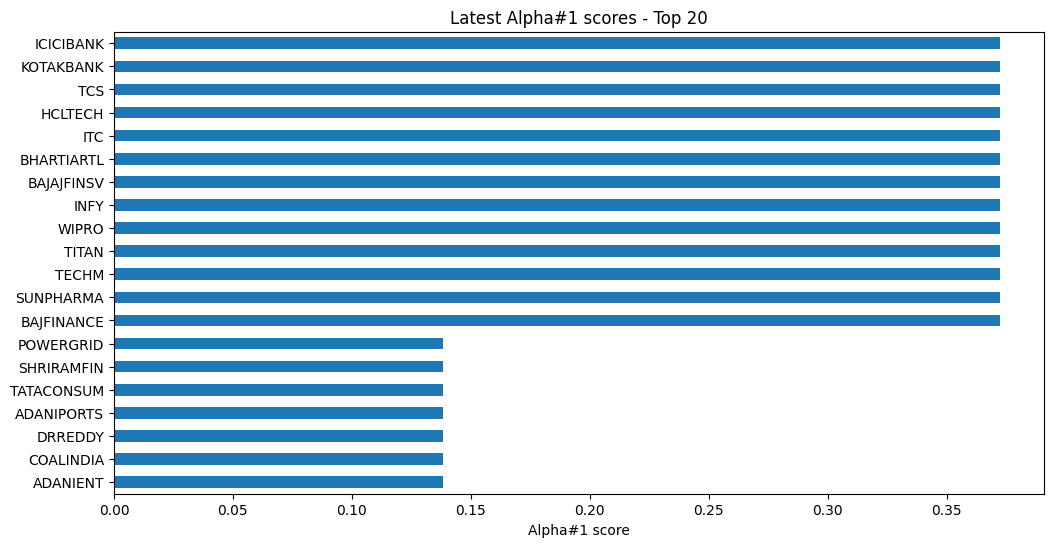

,latest_alpha001_top10
BAJFINANCE,0.37234
BAJAJFINSV,0.37234
BHARTIARTL,0.37234
ITC,0.37234
INFY,0.37234
TITAN,0.37234
TECHM,0.37234
SUNPHARMA,0.37234
WIPRO,0.37234
TCS,0.37234


,latest_alpha001_bottom10
INDUSINDBK,-0.191489
HEROMOTOCO,-0.191489
TRENT,-0.191489
TATASTEEL,-0.191489
ONGC,-0.191489
RELIANCE,-0.191489
ULTRACEMCO,-0.191489
GRASIM,-0.446809
NESTLEIND,-0.446809
AXISBANK,-0.478723


In [8]:
# Visual sanity check: latest scores

latest_alpha = alpha001.dropna(how="all").iloc[-1].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
latest_alpha.head(20).sort_values().plot(kind="barh")
plt.title("Latest Alpha#1 scores - Top 20")
plt.xlabel("Alpha#1 score")
plt.show()

display(latest_alpha.head(10).to_frame("latest_alpha001_top10"))
display(latest_alpha.tail(10).to_frame("latest_alpha001_bottom10"))

## 10. Forward returns

We now create future returns for multiple horizons.

For horizon `h`:

```text
forward_return_h = close[t+h] / close[t] - 1
```

We test 1, 3, 5, and 10 trading days.

In [9]:
forward_returns = {
    h: return_close.shift(-h) / return_close - 1.0
    for h in FORWARD_HORIZONS
}

for h, fwd in forward_returns.items():
    print(h, fwd.shape)

1 (2068, 47)
3 (2068, 47)
5 (2068, 47)
10 (2068, 47)


## 11. Information Coefficient analysis

The Information Coefficient asks:

```text
Across stocks on date t, does Alpha#1 correlate with future returns?
```

We compute both:

- Pearson IC
- Spearman / rank IC

For cross-sectional alphas, Rank IC is usually more robust.

In [11]:
def cross_sectional_corr_by_date(
    signal: pd.DataFrame,
    future_returns: pd.DataFrame,
    method: str = "spearman",
    min_obs: int = 10,
) -> pd.Series:
    values = {}
    common_dates = signal.index.intersection(future_returns.index)
    for date in common_dates:
        x = signal.loc[date]
        y = future_returns.loc[date]
        pair = pd.concat([x, y], axis=1).dropna()
        if len(pair) < min_obs:
            values[date] = np.nan
        else:
            values[date] = pair.iloc[:, 0].corr(pair.iloc[:, 1], method=method)
    return pd.Series(values).dropna()


ic_rows = []
ic_series_by_horizon = {}

for h, fwd in forward_returns.items():
    pearson_ic = cross_sectional_corr_by_date(alpha001, fwd, method="pearson")
    rank_ic = cross_sectional_corr_by_date(alpha001, fwd, method="spearman")
    ic_series_by_horizon[h] = rank_ic

    ic_rows.append({
        "horizon_days": h,
        "mean_pearson_ic": pearson_ic.mean(),
        "mean_rank_ic": rank_ic.mean(),
        "rank_ic_std": rank_ic.std(),
        "rank_icir": rank_ic.mean() / rank_ic.std() if rank_ic.std() else np.nan,
        "positive_rank_ic_rate": (rank_ic > 0).mean(),
        "observations": len(rank_ic),
    })

ic_summary = pd.DataFrame(ic_rows).set_index("horizon_days")
ic_summary.to_csv(OUTPUT_DIR / "ic_by_horizon.csv")
display(ic_summary)

,mean_pearson_ic,mean_rank_ic,rank_ic_std,rank_icir,positive_rank_ic_rate,observations
horizon_days,,,,,,
1,-0.013360,-0.020459,0.175749,-0.116411,0.449829,2043
3,-0.014399,-0.019235,0.171941,-0.111869,0.454234,2043
5,-0.012967,-0.015988,0.175498,-0.091102,0.464968,2041
10,-0.008206,-0.011497,0.178400,-0.064443,0.485265,2036


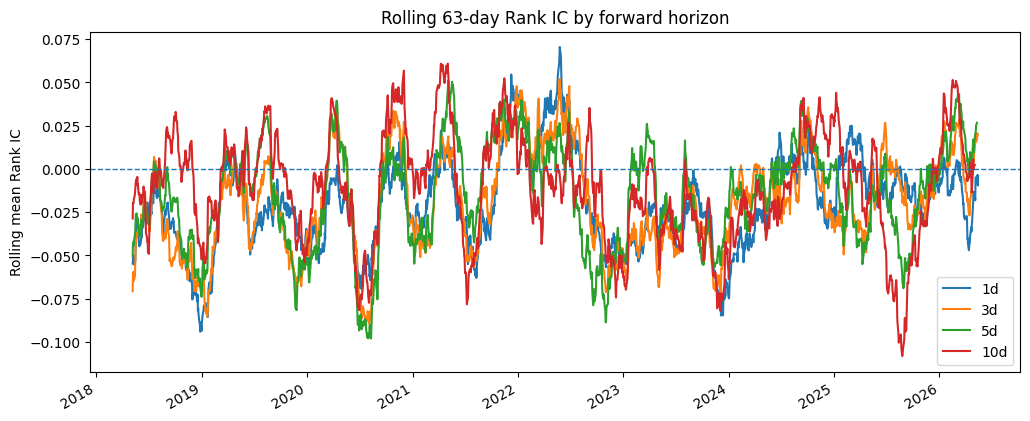

In [12]:
plt.figure(figsize=(12, 5))
for h, series in ic_series_by_horizon.items():
    series.rolling(63).mean().plot(label=f"{h}d")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 63-day Rank IC by forward horizon")
plt.ylabel("Rolling mean Rank IC")
plt.legend()
plt.show()

### How to interpret IC

A good first read:

- Mean Rank IC above zero: higher Alpha#1 scores tend to precede higher future returns.
- Mean Rank IC below zero: the alpha may need to be inverted.
- ICIR measures stability, not just average effect.
- Positive IC rate shows how often the signal direction works.

If the 1d/3d/5d ICs are unstable, the signal may not be reliable enough for trade generation yet.

## 12. Bucket return analysis

Now we test whether top-ranked stocks outperform bottom-ranked stocks.

For each date and horizon:

- Top bucket = top N Alpha#1 stocks
- Bottom bucket = bottom N Alpha#1 stocks
- Spread = top average future return - bottom average future return

This tells us whether Alpha#1 has a useful monotonic relationship with future returns.

In [13]:
def bucket_returns(signal: pd.DataFrame, future_return: pd.DataFrame, top_n: int) -> pd.DataFrame:
    rows = []
    for date in signal.index.intersection(future_return.index):
        scores = signal.loc[date].dropna()
        rets = future_return.loc[date].dropna()
        common = scores.index.intersection(rets.index)
        if len(common) < top_n * 2:
            continue
        scores = scores[common].sort_values(ascending=False)
        rets = rets[common]
        top_symbols = scores.head(top_n).index
        bottom_symbols = scores.tail(top_n).index
        rows.append({
            "date": date,
            "top_return": rets[top_symbols].mean(),
            "bottom_return": rets[bottom_symbols].mean(),
            "spread_return": rets[top_symbols].mean() - rets[bottom_symbols].mean(),
            "top_symbols": ",".join(top_symbols),
            "bottom_symbols": ",".join(bottom_symbols),
        })
    return pd.DataFrame(rows).set_index("date")


bucket_summary_rows = []
bucket_frames = {}

for h, fwd in forward_returns.items():
    for top_n in TOP_N_VALUES:
        frame = bucket_returns(alpha001, fwd, top_n)
        key = (h, top_n)
        bucket_frames[key] = frame
        bucket_summary_rows.append({
            "horizon_days": h,
            "top_n": top_n,
            "mean_top_return": frame["top_return"].mean(),
            "mean_bottom_return": frame["bottom_return"].mean(),
            "mean_spread_return": frame["spread_return"].mean(),
            "spread_hit_rate": (frame["spread_return"] > 0).mean(),
            "observations": len(frame),
        })

bucket_summary = pd.DataFrame(bucket_summary_rows)
bucket_summary.to_csv(OUTPUT_DIR / "bucket_returns.csv", index=False)
display(bucket_summary)

,horizon_days,top_n,mean_top_return,mean_bottom_return,mean_spread_return,spread_hit_rate,observations
0,1,5,0.000968,0.000857,0.000112,0.489487,2045
1,1,10,0.000716,0.001000,-0.000284,0.475538,2044
2,3,5,0.002239,0.002465,-0.000225,0.484092,2043
3,3,10,0.001981,0.002435,-0.000453,0.473555,2042
4,5,5,0.004235,0.004278,-0.000042,0.492896,2041
5,5,10,0.003644,0.004191,-0.000547,0.482353,2040
6,10,5,0.008539,0.007140,0.001399,0.502456,2036
7,10,10,0.007790,0.007638,0.000152,0.492383,2035


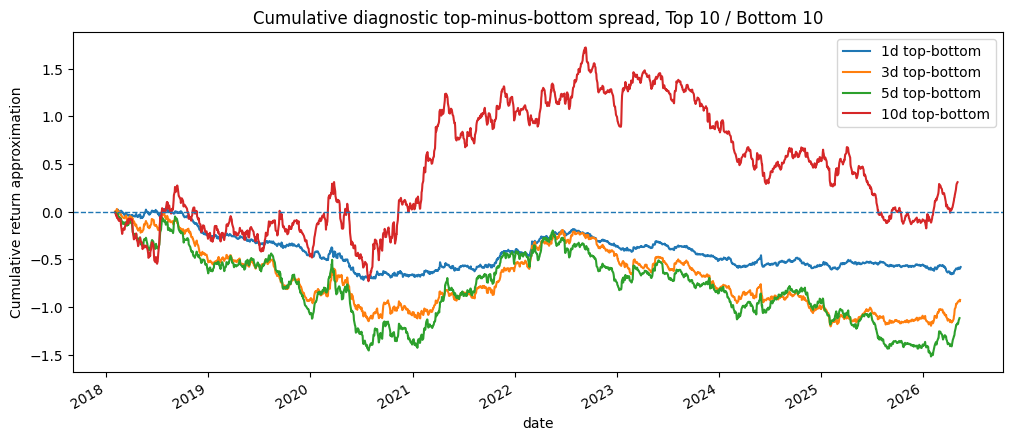

In [14]:
# Plot cumulative bucket spread for each horizon using top 10 / bottom 10

plt.figure(figsize=(12, 5))
for h in FORWARD_HORIZONS:
    frame = bucket_frames[(h, 10)]
    # For multi-day horizons this is overlapping; use as diagnostic, not exact portfolio PnL.
    frame["spread_return"].fillna(0).cumsum().plot(label=f"{h}d top-bottom")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative diagnostic top-minus-bottom spread, Top 10 / Bottom 10")
plt.ylabel("Cumulative return approximation")
plt.legend()
plt.show()

## 13. Simple daily portfolio backtest

This section converts the signal into simple daily-rebalanced portfolios.

We test:

- Long top N
- Long top N / short bottom N

Important simplification:
- The portfolio is formed using today's Alpha#1.
- It earns next-day close-to-close return.
- Transaction cost is estimated using daily turnover.

This is not a final trading simulator, but it is useful for first-pass validation.

In [15]:
next_day_returns = return_close.pct_change().shift(-1)


def build_weights(signal: pd.DataFrame, top_n: int, long_short: bool) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        if len(scores) < top_n * (2 if long_short else 1):
            continue
        top = scores.head(top_n).index
        weights.loc[date, top] = 1.0 / top_n
        if long_short:
            bottom = scores.tail(top_n).index
            weights.loc[date, bottom] = -1.0 / top_n
    return weights


def backtest_daily_strategy(
    signal: pd.DataFrame,
    next_returns: pd.DataFrame,
    top_n: int,
    long_short: bool,
    cost_bps: float,
) -> pd.Series:
    weights = build_weights(signal, top_n=top_n, long_short=long_short)
    aligned_returns = next_returns.reindex_like(weights)
    gross = (weights * aligned_returns).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = turnover * (cost_bps / 10000.0)
    net = gross - costs
    return net.dropna()


def performance_metrics(returns: pd.Series, periods_per_year: int = 252) -> dict:
    returns = returns.dropna()
    if returns.empty:
        return {}
    equity = (1.0 + returns).cumprod()
    years = len(returns) / periods_per_year
    total_return = equity.iloc[-1] - 1.0
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = returns.std() * math.sqrt(periods_per_year)
    sharpe = (returns.mean() * periods_per_year) / vol if vol and vol > 0 else np.nan
    downside = returns[returns < 0].std() * math.sqrt(periods_per_year)
    sortino = (returns.mean() * periods_per_year) / downside if downside and downside > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    return {
        "observations": len(returns),
        "total_return": total_return,
        "cagr": cagr,
        "annual_vol": vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": drawdown.min(),
        "daily_win_rate": (returns > 0).mean(),
        "mean_daily_return": returns.mean(),
    }


strategy_returns = {}
metric_rows = []

for top_n in TOP_N_VALUES:
    for long_short in [False, True]:
        name = f"{'long_short' if long_short else 'long_only'}_top{top_n}"
        rets = backtest_daily_strategy(
            alpha001,
            next_day_returns,
            top_n=top_n,
            long_short=long_short,
            cost_bps=ROUND_TRIP_COST_BPS,
        )
        strategy_returns[name] = rets
        row = {"strategy": name, "top_n": top_n, "long_short": long_short}
        row.update(performance_metrics(rets))
        metric_rows.append(row)

strategy_metrics = pd.DataFrame(metric_rows).set_index("strategy")
strategy_metrics.to_csv(OUTPUT_DIR / "strategy_metrics.csv")
display(strategy_metrics)

,top_n,long_short,observations,total_return,cagr,annual_vol,sharpe,sortino,max_drawdown,daily_win_rate,mean_daily_return
strategy,,,,,,,,,,,
long_only_top5,5,False,2068,-0.526916,-0.087172,0.216478,-0.311896,-0.406762,-0.691514,0.483075,-0.000268
long_short_top5,5,True,2068,-0.995994,-0.489641,0.188367,-3.472055,-5.367782,-0.996321,0.363153,-0.002595
long_only_top10,10,False,2068,-0.635884,-0.115833,0.191319,-0.546656,-0.677200,-0.662451,0.489362,-0.000415
long_short_top10,10,True,2068,-0.994977,-0.475379,0.143202,-4.427102,-6.417296,-0.995105,0.352515,-0.002516


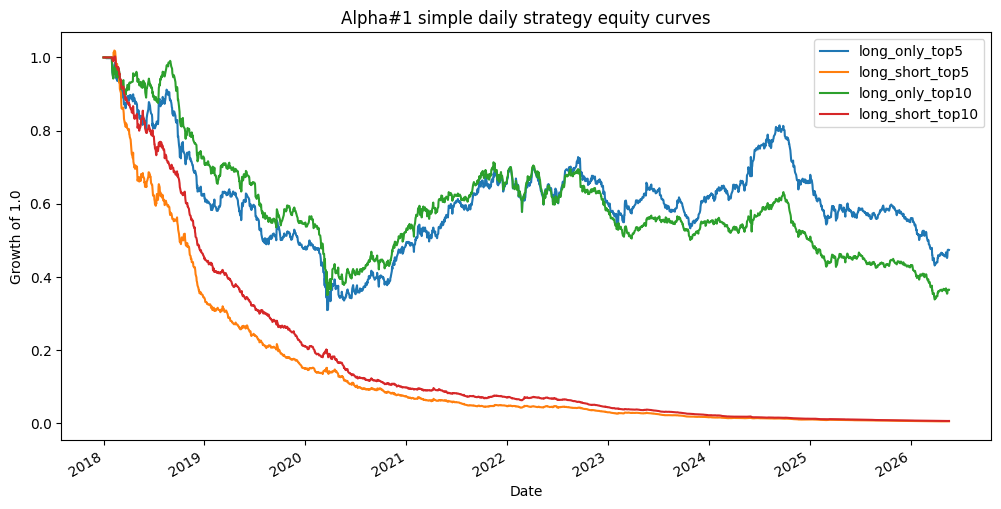

In [16]:
plt.figure(figsize=(12, 6))
for name, rets in strategy_returns.items():
    (1 + rets.fillna(0)).cumprod().plot(label=name)
plt.title("Alpha#1 simple daily strategy equity curves")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.show()

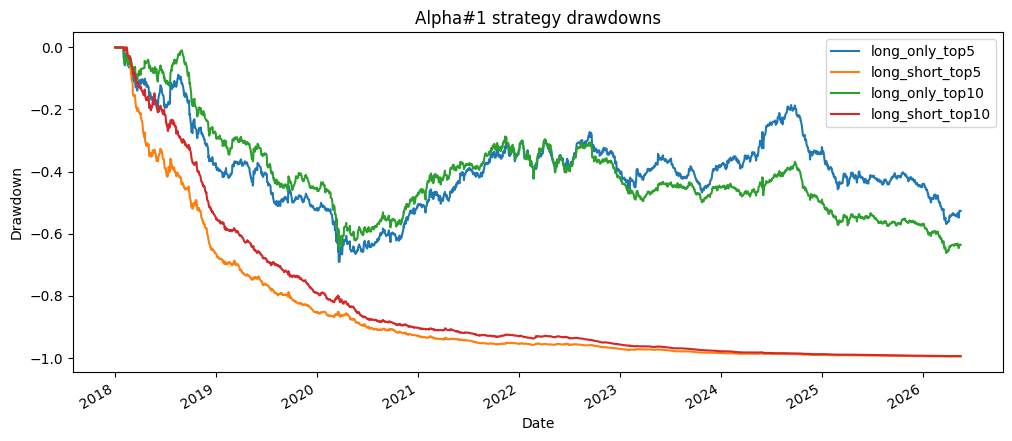

In [17]:
plt.figure(figsize=(12, 5))
for name, rets in strategy_returns.items():
    equity = (1 + rets.fillna(0)).cumprod()
    drawdown = equity / equity.cummax() - 1
    drawdown.plot(label=name)
plt.title("Alpha#1 strategy drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

## 14. Market regime detection

We now classify market environments using the NIFTY index.

Trend regime:
- `bull`: NIFTY close > 50DMA and 50DMA > 200DMA
- `bear`: NIFTY close < 50DMA and 50DMA < 200DMA
- `sideways`: otherwise

Volatility regime:
- rolling 20-day volatility split into low / medium / high by quantiles

In [18]:
nifty_raw = yf.download(
    NIFTY_INDEX_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)

if isinstance(nifty_raw.columns, pd.MultiIndex):
    nifty_close = nifty_raw[(NIFTY_INDEX_TICKER, "Close")]
else:
    nifty_close = nifty_raw["Close"]

nifty_close = nifty_close.reindex(close_px.index).ffill()

sma50 = nifty_close.rolling(50).mean()
sma200 = nifty_close.rolling(200).mean()
nifty_ret = nifty_close.pct_change()
nifty_vol20 = nifty_ret.rolling(20).std() * np.sqrt(252)

trend_regime = pd.Series("sideways", index=nifty_close.index)
trend_regime[(nifty_close > sma50) & (sma50 > sma200)] = "bull"
trend_regime[(nifty_close < sma50) & (sma50 < sma200)] = "bear"

vol_q1 = nifty_vol20.quantile(0.33)
vol_q2 = nifty_vol20.quantile(0.66)
vol_regime = pd.Series("medium_vol", index=nifty_close.index)
vol_regime[nifty_vol20 <= vol_q1] = "low_vol"
vol_regime[nifty_vol20 >= vol_q2] = "high_vol"

regimes = pd.DataFrame({
    "nifty_close": nifty_close,
    "trend_regime": trend_regime,
    "nifty_vol20": nifty_vol20,
    "vol_regime": vol_regime,
})

display(regimes.tail())
display(regimes[["trend_regime", "vol_regime"]].value_counts().to_frame("days"))

/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


KeyError: ('^NSEI', 'Close')

## 15. Regime performance

Now we ask:

- Is Alpha#1's IC better in bull, bear, or sideways markets?
- Does the strategy work better in low, medium, or high volatility?
- Are failures concentrated in specific regimes?

In [ ]:
# Use 5-day Rank IC as a default research horizon for regime analysis.
DEFAULT_REGIME_HORIZON = 5

rank_ic_5d = ic_series_by_horizon[DEFAULT_REGIME_HORIZON].rename("rank_ic")
regime_ic = pd.concat([rank_ic_5d, regimes[["trend_regime", "vol_regime"]]], axis=1).dropna()

regime_rows = []

for regime_col in ["trend_regime", "vol_regime"]:
    grouped = regime_ic.groupby(regime_col)["rank_ic"]
    for regime_name, values in grouped:
        regime_rows.append({
            "regime_type": regime_col,
            "regime": regime_name,
            "mean_rank_ic": values.mean(),
            "rank_icir": values.mean() / values.std() if values.std() else np.nan,
            "positive_ic_rate": (values > 0).mean(),
            "observations": len(values),
        })

# Add strategy regime performance for long_short_top10.
default_strategy = strategy_returns.get("long_short_top10")
if default_strategy is not None:
    strat_regime = pd.concat([
        default_strategy.rename("strategy_return"),
        regimes[["trend_regime", "vol_regime"]],
    ], axis=1).dropna()
    for regime_col in ["trend_regime", "vol_regime"]:
        grouped = strat_regime.groupby(regime_col)["strategy_return"]
        for regime_name, values in grouped:
            regime_rows.append({
                "regime_type": regime_col + "_strategy",
                "regime": regime_name,
                "mean_rank_ic": np.nan,
                "rank_icir": np.nan,
                "positive_ic_rate": (values > 0).mean(),
                "observations": len(values),
                "mean_strategy_return": values.mean(),
                "strategy_sharpe": (values.mean() * 252) / (values.std() * np.sqrt(252)) if values.std() else np.nan,
            })

regime_report = pd.DataFrame(regime_rows)
regime_report.to_csv(OUTPUT_DIR / "regime_report.csv", index=False)
display(regime_report)

## 16. Stock-level ranking

We now identify which NIFTY50 stocks seem most compatible with Alpha#1.

For each stock we calculate:

- correlation between its Alpha#1 score and future return
- average future return when it is in the top bucket
- average future return when it is in the bottom bucket
- hit rate when selected
- number of observations

This is not final proof. It is a ranking screen for deeper research.

In [ ]:
def stock_level_alpha_report(
    signal: pd.DataFrame,
    future_return: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    rows = []
    top_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)
    bottom_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)

    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        if len(scores) < top_n * 2:
            continue
        top_mask.loc[date, scores.head(top_n).index] = True
        bottom_mask.loc[date, scores.tail(top_n).index] = True

    for symbol in signal.columns:
        pair = pd.concat(
            [signal[symbol].rename("alpha"), future_return[symbol].rename("fwd")],
            axis=1,
        ).dropna()

        top_rets = future_return[symbol][top_mask[symbol]].dropna()
        bottom_rets = future_return[symbol][bottom_mask[symbol]].dropna()

        rows.append({
            "symbol": symbol,
            "alpha_fwd_corr": pair["alpha"].corr(pair["fwd"], method="spearman") if len(pair) >= 30 else np.nan,
            "top_selected_mean_fwd_return": top_rets.mean(),
            "top_selected_hit_rate": (top_rets > 0).mean() if len(top_rets) else np.nan,
            "top_selected_count": len(top_rets),
            "bottom_selected_mean_fwd_return": bottom_rets.mean(),
            "bottom_selected_hit_rate": (bottom_rets > 0).mean() if len(bottom_rets) else np.nan,
            "bottom_selected_count": len(bottom_rets),
        })

    report = pd.DataFrame(rows).set_index("symbol")

    # Simple normalized composite ranking score.
    components = pd.DataFrame(index=report.index)
    components["corr"] = report["alpha_fwd_corr"].rank(pct=True)
    components["top_return"] = report["top_selected_mean_fwd_return"].rank(pct=True)
    components["top_hit"] = report["top_selected_hit_rate"].rank(pct=True)
    components["avoid_bottom"] = (-report["bottom_selected_mean_fwd_return"]).rank(pct=True)
    components["sample"] = report["top_selected_count"].rank(pct=True)

    report["alpha001_stock_score"] = (
        0.30 * components["corr"]
        + 0.30 * components["top_return"]
        + 0.20 * components["top_hit"]
        + 0.10 * components["avoid_bottom"]
        + 0.10 * components["sample"]
    )

    return report.sort_values("alpha001_stock_score", ascending=False)


stock_ranking = stock_level_alpha_report(
    alpha001,
    forward_returns[DEFAULT_REGIME_HORIZON],
    top_n=10,
)

stock_ranking.to_csv(OUTPUT_DIR / "stock_ranking.csv")
display(stock_ranking.head(15))
display(stock_ranking.tail(15))

In [ ]:
plt.figure(figsize=(10, 8))
stock_ranking["alpha001_stock_score"].head(20).sort_values().plot(kind="barh")
plt.title("Top 20 stocks by Alpha#1 compatibility score")
plt.xlabel("Composite score")
plt.show()

## 17. Confidence model v0

This is not a production model. It is a transparent first pass.

A stock gets higher confidence when:

1. It is currently in the top Alpha#1 bucket.
2. The recent 5-day Rank IC is positive.
3. The stock has historically ranked well for Alpha#1.
4. The current market regime has been favorable.
5. It has enough data.

Output should be interpreted as:

```text
candidate idea quality, not probability of profit
```

In [ ]:
def minmax_score(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    lo, hi = series.min(), series.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(0.5, index=series.index)
    return (series - lo) / (hi - lo)


latest_date = alpha001.dropna(how="all").index[-1]
latest_scores = alpha001.loc[latest_date].dropna().sort_values(ascending=False)
latest_top = latest_scores.head(10)

recent_ic = ic_series_by_horizon[DEFAULT_REGIME_HORIZON].loc[:latest_date].tail(63)
recent_ic_score = float(np.clip((recent_ic.mean() + 0.05) / 0.10, 0, 1)) if len(recent_ic) else 0.5

current_trend = regimes.loc[latest_date, "trend_regime"]
current_vol = regimes.loc[latest_date, "vol_regime"]

regime_ic_lookup = regime_report[
    regime_report["regime_type"].isin(["trend_regime", "vol_regime"])
].set_index(["regime_type", "regime"])

trend_score_raw = regime_ic_lookup.loc[("trend_regime", current_trend), "mean_rank_ic"] if ("trend_regime", current_trend) in regime_ic_lookup.index else 0
vol_score_raw = regime_ic_lookup.loc[("vol_regime", current_vol), "mean_rank_ic"] if ("vol_regime", current_vol) in regime_ic_lookup.index else 0

regime_score = float(np.clip(((trend_score_raw + vol_score_raw) / 2 + 0.05) / 0.10, 0, 1))

stock_score_scaled = minmax_score(stock_ranking["alpha001_stock_score"])

candidate_rows = []
for symbol, score in latest_top.items():
    candidate_rows.append({
        "date": latest_date,
        "symbol": symbol,
        "alpha": "alpha001",
        "signal_score": score,
        "suggested_direction": "long",
        "horizon_days": DEFAULT_REGIME_HORIZON,
        "recent_ic_score": recent_ic_score,
        "regime_score": regime_score,
        "stock_score": stock_score_scaled.get(symbol, 0.5),
        "confidence_v0": (
            0.35 * recent_ic_score
            + 0.30 * stock_score_scaled.get(symbol, 0.5)
            + 0.25 * regime_score
            + 0.10 * float(score > 0)
        ),
        "reason": (
            f"Top Alpha#1 bucket; current trend={current_trend}; "
            f"current volatility={current_vol}; recent 5d IC mean={recent_ic.mean():.4f}"
        ),
    })

latest_candidates = pd.DataFrame(candidate_rows).sort_values("confidence_v0", ascending=False)
latest_candidates.to_csv(OUTPUT_DIR / "latest_trade_candidates.csv", index=False)
display(latest_candidates)

## 18. Decision checklist

Before promoting Alpha#1 from research/draft to testing, answer:

1. Is mean Rank IC positive for at least one short horizon?
2. Is the top-minus-bottom bucket spread positive after reasonable costs?
3. Does long-only top bucket work, or only long-short?
4. Is performance concentrated in a few stocks?
5. Is performance concentrated in one regime?
6. Is turnover too high?
7. Does the signal survive different start dates?
8. Does it survive excluding the top 3 best stocks?
9. Does it still work with stricter data-quality filters?
10. Is the logic reproducible enough to move into `project/signals` later?

Suggested promotion rule:

```text
draft -> testing only if:
- mean 5d Rank IC > 0
- ICIR > 0.20
- top-minus-bottom spread > estimated transaction costs
- positive IC rate > 52%
- no single stock explains the result
- regime analysis does not show obvious overfit
```

## 19. Export summary

The notebook has written research artifacts to:

```text
research/artifacts/alpha001_nifty50/
```

These are review artifacts, not canonical database records.

Next implementation step after notebook validation:

```text
project/signals/alpha001.py
project/research/alpha001_config.yaml
tests/test_alpha001.py
```

In [ ]:
print("Generated files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path)